# 🔬 UCI-HAR: Ablation Study
## CNN · GRU · Gated Attention — Component-wise Analysis

---

### 🎯 Purpose
This notebook systematically isolates each architectural component to understand what each one contributes to performance.

### 📐 Five Variants Tested (in order)
| # | Model | CNN | GRU | Gated Attn |
|---|-------|:---:|:---:|:----------:|
| 1 | **CNN Only** | ✅ | ❌ | ❌ |
| 2 | **CNN + GRU** | ✅ | ✅ | ❌ |
| 3 | **CNN + Gated Attention** | ✅ | ❌ | ✅ |
| 4 | **GRU + Gated Attention** | ❌ | ✅ | ✅ |
| 5 | **GRU Only** | ❌ | ✅ | ❌ |

> *(Full hybrid = CNN + GRU + Gated Attention — run your original notebook to compare)*

### 🔑 Design Principles
- **Same data pipeline** for all models (subject-level splits, no leakage)
- **Same training config** (epochs, batch size, cosine LR, early stopping)
- **Same classifier head** (Dense-128 → BN → ReLU → Dense-6)
- **Same evaluation suite** (accuracy, F1, kappa, MCC, AUC, confusion matrix)
- All results collected in a final **comparison table + bar chart**

---
## 📦 Step 1 — Install & Import Libraries

In [ ]:
!pip install -q scikit-learn matplotlib seaborn tensorflow

import os, zipfile, random, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_curve, auc,
    cohen_kappa_score, matthews_corrcoef,
    precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 📂 Step 2 — Upload & Extract Dataset
Upload your `UCI-HAR.zip` when prompted.

In [ ]:
from google.colab import files

print('Please upload UCI-HAR.zip ...')
uploaded = files.upload()

zip_name    = list(uploaded.keys())[0]
extract_dir = '/content/UCI_HAR'

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

def find_dataset_root(base):
    for root, dirs, files_list in os.walk(base):
        if 'activity_labels.txt' in files_list:
            return root
    raise FileNotFoundError('activity_labels.txt not found — check zip structure.')

DATASET_PATH = find_dataset_root(extract_dir)
print(f'Dataset root: {DATASET_PATH}')
print(os.listdir(DATASET_PATH))

Please upload UCI-HAR.zip ...


Saving UCI-HAR.zip to UCI-HAR.zip
Dataset root: /content/UCI_HAR/UCI-HAR/UCI HAR Dataset
['.DS_Store', 'features_info.txt', 'test', 'activity_labels.txt', 'README.txt', 'train', '__MACOSX', 'features.txt']


---
## 🔬 Step 3 — Load Raw Inertial Signals (9 Channels × 128 Timesteps)

In [ ]:
SIGNAL_NAMES = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
]

ACTIVITY_LABELS = {
    1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING', 5: 'STANDING', 6: 'LAYING'
}
N_CLASSES   = 6
N_TIMESTEPS = 128
N_CHANNELS  = 9

def load_signals(split):
    sig_dir = os.path.join(DATASET_PATH, split, 'Inertial Signals')
    data = []
    for name in SIGNAL_NAMES:
        fpath = os.path.join(sig_dir, f'{name}_{split}.txt')
        arr = pd.read_csv(fpath, header=None, sep='\s+').values
        data.append(arr)
    return np.stack(data, axis=2).astype(np.float32)  # (N, 128, 9)

def load_labels(split):
    fpath = os.path.join(DATASET_PATH, split, f'y_{split}.txt')
    return pd.read_csv(fpath, header=None).values.flatten() - 1  # 0-indexed

def load_subjects(split):
    fpath = os.path.join(DATASET_PATH, split, f'subject_{split}.txt')
    return pd.read_csv(fpath, header=None).values.flatten()

print('Loading train signals ...')
X_train_full = load_signals('train')
y_train_full = load_labels('train')
subj_train   = load_subjects('train')

print('Loading test signals ...')
X_test    = load_signals('test')
y_test    = load_labels('test')
subj_test = load_subjects('test')

print(f'Train: {X_train_full.shape}, labels: {y_train_full.shape}')
print(f'Test : {X_test.shape},  labels: {y_test.shape}')
print(f'Train subjects: {sorted(np.unique(subj_train))}')
print(f'Test  subjects: {sorted(np.unique(subj_test))}')

Loading train signals ...


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4891/1285066398.py:20: SyntaxWarning: invalid escape sequence '\s'
  arr = pd.read_csv(fpath, header=None, sep='\s+').values


Loading test signals ...
Train: (7352, 128, 9), labels: (7352,)
Test : (2947, 128, 9),  labels: (2947,)
Train subjects: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test  subjects: [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]


---
## 🛡️ Step 4 — Subject-Level Split (No Data Leakage)

In [ ]:
train_subjects = sorted(np.unique(subj_train))
test_subjects  = sorted(np.unique(subj_test))

overlap = set(train_subjects) & set(test_subjects)
assert len(overlap) == 0, f'DATA LEAK: subjects {overlap} appear in both train and test!'
print(f'✅ No overlap between train ({len(train_subjects)} subj) and test ({len(test_subjects)} subj)')

np.random.seed(SEED)
val_subjects = np.random.choice(train_subjects, size=4, replace=False).tolist()
tr_subjects  = [s for s in train_subjects if s not in val_subjects]

print(f'Train subjects ({len(tr_subjects)}): {tr_subjects}')
print(f'Val   subjects ({len(val_subjects)}): {val_subjects}')
print(f'Test  subjects ({len(test_subjects)}): {test_subjects}')

tr_mask  = np.isin(subj_train, tr_subjects)
val_mask = np.isin(subj_train, val_subjects)

X_train = X_train_full[tr_mask]
y_train = y_train_full[tr_mask]
X_val   = X_train_full[val_mask]
y_val   = y_train_full[val_mask]

print(f'\nFinal splits:')
print(f'  Train: {X_train.shape}')
print(f'  Val  : {X_val.shape}')
print(f'  Test : {X_test.shape}')

✅ No overlap between train (21 subj) and test (9 subj)
Train subjects (17): [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(28), np.int64(29), np.int64(30)]
Val   subjects (4): [1, 27, 25, 3]
Test  subjects (9): [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]

Final splits:
  Train: (5879, 128, 9)
  Val  : (1473, 128, 9)
  Test : (2947, 128, 9)


---
## 📊 Step 5 — Normalize (Per-Channel, Fit on Train Only)

In [ ]:
train_mean = X_train.mean(axis=(0, 1), keepdims=True)  # (1, 1, 9)
train_std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - train_mean) / train_std
X_val_n   = (X_val   - train_mean) / train_std
X_test_n  = (X_test  - train_mean) / train_std

y_train_cat = to_categorical(y_train, N_CLASSES)
y_val_cat   = to_categorical(y_val,   N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

print('Normalization done (fit on train only — no leakage).')
print(f'X_train range: [{X_train_n.min():.3f}, {X_train_n.max():.3f}]')
print(f'X_val   range: [{X_val_n.min():.3f},   {X_val_n.max():.3f}]')
print(f'X_test  range: [{X_test_n.min():.3f},  {X_test_n.max():.3f}]')

Normalization done (fit on train only — no leakage).
X_train range: [-15.315, 14.734]
X_val   range: [-8.654,   7.210]
X_test  range: [-10.208,  8.894]


---
## 🔍 Step 6 — Quick EDA (Class Distribution)

/tmp/ipykernel_4891/3289567880.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(activity_names, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_4891/3289567880.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(activity_names, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_4891/3289567880.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(activity_names, rotation=30, ha='right', fontsize=9)


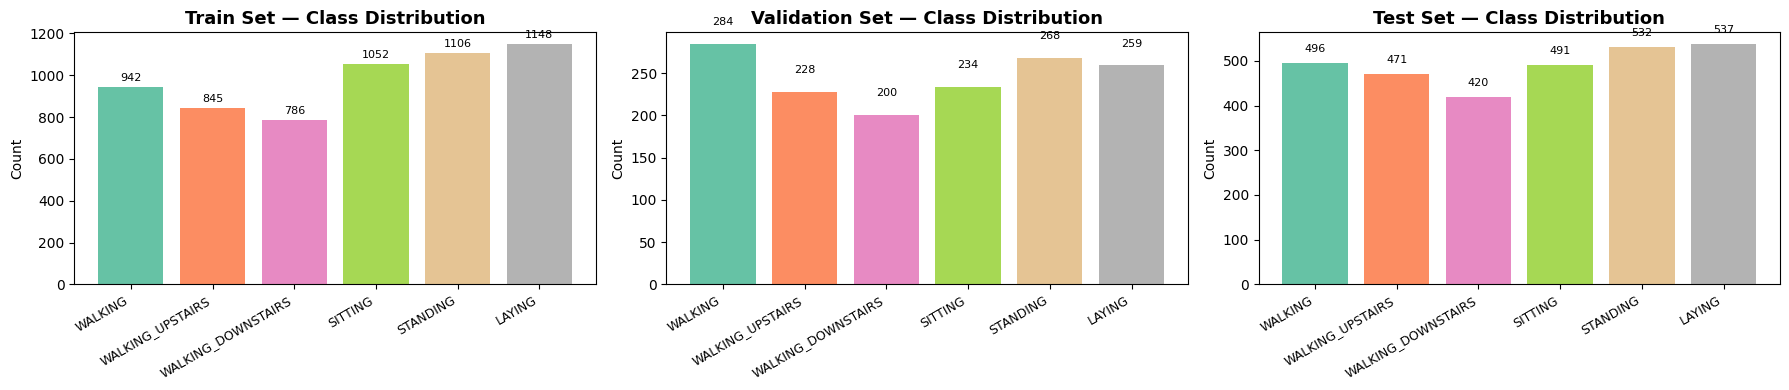

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
activity_names = [ACTIVITY_LABELS[i+1] for i in range(N_CLASSES)]

for ax, (y_split, title) in zip(axes, [
    (y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')
]):
    counts = [np.sum(y_split == i) for i in range(N_CLASSES)]
    bars = ax.bar(activity_names, counts, color=plt.cm.Set2(np.linspace(0, 1, 6)))
    ax.set_title(f'{title} Set — Class Distribution', fontsize=13, fontweight='bold')
    ax.set_xticklabels(activity_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🏗️ Step 7 — Shared Building Blocks

All model variants reuse these helper functions so the comparison is fair:
- `cnn_block()` — two CNN blocks identical to the original
- `gru_block()` — two Bidirectional GRU layers
- `GatedAttention` — exact same custom layer as original
- `classifier_head()` — shared Dense-128 → BN → ReLU → Dense-6 head

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SHARED LAYER BUILDERS
# ─────────────────────────────────────────────────────────────────────────────

def cnn_blocks(x):
    """Two CNN blocks identical to the original model."""
    # Block 1
    x = layers.Conv1D(64, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)   # 128 → 64
    x = layers.Dropout(0.2)(x)
    # Block 2
    x = layers.Conv1D(128, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)   # 64 → 32
    x = layers.Dropout(0.2)(x)
    return x


def gru_blocks(x, return_sequences_final=True):
    """Two Bidirectional GRU layers. return_sequences_final controls last GRU."""
    x = layers.Bidirectional(
            layers.GRU(128, return_sequences=True,
                       dropout=0.2, recurrent_dropout=0.0))(x)
    x = layers.Bidirectional(
            layers.GRU(64, return_sequences=return_sequences_final,
                       dropout=0.2, recurrent_dropout=0.0))(x)
    return x


def classifier_head(x, n_classes=N_CLASSES, dropout_rate=0.4):
    """Shared Dense head — same for all variants."""
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return out


class GatedAttention(layers.Layer):
    """
    Gated Attention Mechanism — identical to original.
    Given hidden states H (batch, T, d):
      score   = tanh(H @ W_h)           — content relevance
      gate    = sigmoid(H @ W_g)        — information gate
      alpha   = softmax(score * gate)   — gated attention weights
      context = sum_t(alpha_t * H_t)    — weighted context vector
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        d = input_shape[-1]
        self.W_h = self.add_weight(
            shape=(d, self.units), name='W_h',
            initializer='glorot_uniform', trainable=True)
        self.W_g = self.add_weight(
            shape=(d, self.units), name='W_g',
            initializer='glorot_uniform', trainable=True)
        self.v   = self.add_weight(
            shape=(self.units, 1), name='v',
            initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, H):
        score   = tf.tanh(tf.matmul(H, self.W_h))     # (batch, T, units)
        gate    = tf.sigmoid(tf.matmul(H, self.W_g))  # (batch, T, units)
        gated   = score * gate
        e       = tf.matmul(gated, self.v)             # (batch, T, 1)
        attn_w  = tf.nn.softmax(e, axis=1)             # (batch, T, 1)
        context = tf.reduce_sum(attn_w * H, axis=1)   # (batch, d)
        return context, tf.squeeze(attn_w, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


print('✅ Shared building blocks defined.')

✅ Shared building blocks defined.


---
## 🧩 Step 8 — Five Ablation Model Builders

```
Variant 1 — CNN Only:
  Input → CNN Block 1 → CNN Block 2 → GlobalAvgPool → Head

Variant 2 — CNN + GRU:
  Input → CNN → BiGRU(128, seq) → BiGRU(64, final) → Head

Variant 3 — CNN + Gated Attention:
  Input → CNN → GatedAttention → Head
  (Attention applied directly on CNN feature maps, no GRU)

Variant 4 — GRU + Gated Attention:
  Input → BiGRU(128, seq) → BiGRU(64, seq) → GatedAttention → Head
  (No CNN — raw signal fed straight to GRU)

Variant 5 — GRU Only:
  Input → BiGRU(128, seq) → BiGRU(64, final) → Head
  (No CNN, no attention)
```

In [ ]:
INPUT_SHAPE = (N_TIMESTEPS, N_CHANNELS)

# ── Variant 1 ─────────────────────────────────────────────────────────────────
def build_cnn_only():
    """
    CNN Only.
    CNN extracts local features → GlobalAveragePooling collapses the
    temporal dimension → shared classifier head.
    """
    inp = layers.Input(shape=INPUT_SHAPE, name='input')
    x   = cnn_blocks(inp)                      # (batch, 32, 128)
    x   = layers.GlobalAveragePooling1D()(x)   # (batch, 128)
    out = classifier_head(x)
    return Model(inputs=inp, outputs=out, name='CNN_Only')


# ── Variant 2 ─────────────────────────────────────────────────────────────────
def build_cnn_gru():
    """
    CNN + GRU.
    CNN extracts local features, GRU models the temporal dynamics.
    No attention — GRU final hidden state used directly.
    """
    inp = layers.Input(shape=INPUT_SHAPE, name='input')
    x   = cnn_blocks(inp)                             # (batch, 32, 128)
    x   = gru_blocks(x, return_sequences_final=False) # (batch, 128)
    out = classifier_head(x)
    return Model(inputs=inp, outputs=out, name='CNN_GRU')


# ── Variant 3 ─────────────────────────────────────────────────────────────────
def build_cnn_attention():
    """
    CNN + Gated Attention.
    CNN extracts local features, attention selects the most informative
    timestep-positions directly from the CNN maps — no sequential GRU.
    """
    inp               = layers.Input(shape=INPUT_SHAPE, name='input')
    x                 = cnn_blocks(inp)                            # (batch, 32, 128)
    context, _        = GatedAttention(units=64, name='gated_attention')(x)
    out               = classifier_head(context)
    return Model(inputs=inp, outputs=out, name='CNN_GatedAttention')


# ── Variant 4 ─────────────────────────────────────────────────────────────────
def build_gru_attention():
    """
    GRU + Gated Attention.
    Raw signals go directly into the GRU (no CNN preprocessing).
    Attention then selects the most important hidden states.
    """
    inp               = layers.Input(shape=INPUT_SHAPE, name='input')
    x                 = gru_blocks(inp, return_sequences_final=True) # (batch, 128, 128)
    context, _        = GatedAttention(units=64, name='gated_attention')(x)
    out               = classifier_head(context)
    return Model(inputs=inp, outputs=out, name='GRU_GatedAttention')


# ── Variant 5 ─────────────────────────────────────────────────────────────────
def build_gru_only():
    """
    GRU Only.
    Raw signals go directly into the GRU; no CNN, no attention.
    Uses final hidden state for classification.
    """
    inp = layers.Input(shape=INPUT_SHAPE, name='input')
    x   = gru_blocks(inp, return_sequences_final=False)  # (batch, 128)
    out = classifier_head(x)
    return Model(inputs=inp, outputs=out, name='GRU_Only')


# ── Preview all model summaries ───────────────────────────────────────────────
VARIANT_BUILDERS = [
    ('CNN Only',                build_cnn_only),
    ('CNN + GRU',               build_cnn_gru),
    ('CNN + Gated Attention',   build_cnn_attention),
    ('GRU + Gated Attention',   build_gru_attention),
    ('GRU Only',                build_gru_only),
]

print('Parameter counts per variant:\n')
for name, builder in VARIANT_BUILDERS:
    m = builder()
    print(f'  {name:<30}  {m.count_params():>10,} params')
    del m

Parameter counts per variant:

  CNN Only                           107,462 params
  CNN + GRU                          429,254 params
  CNN + Gated Attention              123,910 params
  GRU + Gated Attention              264,646 params
  GRU Only                           248,198 params


---
## ⚙️ Step 9 — Shared Training Config & Helper Functions

In [ ]:
EPOCHS     = 80
BATCH_SIZE = 64
LR_INIT    = 1e-3


def make_callbacks(model_name):
    """Fresh callback set per run so best weights are per-model."""
    safe_name = model_name.replace(' ', '_').replace('+', 'AND')
    ckpt_path = f'best_{safe_name}.weights.h5'
    return [
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=15,
            restore_best_weights=True, verbose=0
        ),
        callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_accuracy',
            save_best_only=True, save_weights_only=True, verbose=0
        ),
    ], ckpt_path


def compile_model(model):
    lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=LR_INIT,
        first_decay_steps=20,
        t_mul=2.0,
        m_mul=0.85
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def evaluate_model(model, name):
    """Run full evaluation — returns a dict of metrics."""
    y_pred_proba  = model.predict(X_test_n,  batch_size=BATCH_SIZE, verbose=0)
    y_pred        = np.argmax(y_pred_proba, axis=1)

    y_tr_pred     = np.argmax(model.predict(X_train_n, batch_size=BATCH_SIZE, verbose=0), axis=1)
    y_v_pred      = np.argmax(model.predict(X_val_n,   batch_size=BATCH_SIZE, verbose=0), axis=1)

    train_acc     = accuracy_score(y_train, y_tr_pred)
    val_acc       = accuracy_score(y_val,   y_v_pred)
    test_acc      = accuracy_score(y_test,  y_pred)

    w_f1          = f1_score(y_test, y_pred, average='weighted')
    mac_f1        = f1_score(y_test, y_pred, average='macro')
    kappa         = cohen_kappa_score(y_test, y_pred)
    mcc           = matthews_corrcoef(y_test, y_pred)

    # AUC (one-vs-rest)
    y_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))
    auc_list = []
    for i in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        auc_list.append(auc(fpr, tpr))
    mean_auc = float(np.mean(auc_list))

    return {
        'name':       name,
        'train_acc':  train_acc,
        'val_acc':    val_acc,
        'test_acc':   test_acc,
        'weighted_f1': w_f1,
        'macro_f1':   mac_f1,
        'kappa':      kappa,
        'mcc':        mcc,
        'mean_auc':   mean_auc,
        'n_params':   model.count_params(),
        'y_pred':     y_pred,
        'y_pred_proba': y_pred_proba,
    }


print(f'Training config: epochs={EPOCHS}, batch={BATCH_SIZE}, LR_init={LR_INIT}')
print('Callbacks: EarlyStopping(patience=15) + ModelCheckpoint')

Training config: epochs=80, batch=64, LR_init=0.001
Callbacks: EarlyStopping(patience=15) + ModelCheckpoint


---
## 🚀 Step 10 — Train All 5 Variants

> Each model is trained independently with the **same hyperparameters** and **same data splits**. Results are collected in `ALL_RESULTS` for the final comparison.
>
> ⏱️ *Expected time on T4 GPU: ~5–12 min per variant (early stopping usually kicks in before epoch 80)*

In [ ]:
ALL_RESULTS  = []     # metrics dicts
ALL_HISTORIES = {}    # training histories keyed by model name

for variant_idx, (variant_name, builder_fn) in enumerate(VARIANT_BUILDERS, 1):
    print(f'\n{"="*65}')
    print(f'  [{variant_idx}/5]  Training: {variant_name}')
    print(f'{"="*65}')

    # Fresh model & callbacks every run
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = compile_model(builder_fn())
    cb_list, ckpt_path = make_callbacks(variant_name)

    t0 = time.time()
    history = model.fit(
        X_train_n, y_train_cat,
        validation_data=(X_val_n, y_val_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cb_list,
        verbose=1
    )
    elapsed = time.time() - t0

    best_val_acc = max(history.history['val_accuracy'])
    stopped_at   = len(history.history['accuracy'])
    print(f'\n  ✅ Done in {elapsed/60:.1f} min | '
          f'Best val acc: {best_val_acc:.4f} | '
          f'Stopped at epoch {stopped_at}')

    # Evaluate
    metrics = evaluate_model(model, variant_name)
    metrics['train_time_min'] = round(elapsed / 60, 2)
    metrics['stopped_epoch']  = stopped_at
    ALL_RESULTS.append(metrics)
    ALL_HISTORIES[variant_name] = history.history

    print(f'  Test Accuracy : {metrics["test_acc"]:.4f}')
    print(f'  Weighted F1   : {metrics["weighted_f1"]:.4f}')
    print(f'  Mean AUC      : {metrics["mean_auc"]:.4f}')

    # Free GPU memory before next model
    del model
    tf.keras.backend.clear_session()

print(f'\n{"="*65}')
print('  ALL 5 VARIANTS TRAINED SUCCESSFULLY!')
print(f'{"="*65}')


  [1/5]  Training: CNN Only
Epoch 1/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.7887 - loss: 0.5808 - val_accuracy: 0.7529 - val_loss: 0.9175
Epoch 2/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9180 - loss: 0.2433 - val_accuracy: 0.9063 - val_loss: 0.3988
Epoch 3/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9313 - loss: 0.1862 - val_accuracy: 0.9470 - val_loss: 0.2050
Epoch 4/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9372 - loss: 0.1682 - val_accuracy: 0.9566 - val_loss: 0.1404
Epoch 5/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9391 - loss: 0.1550 - val_accuracy: 0.9661 - val_loss: 0.1359
Epoch 6/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9452 - loss: 0.1407 - val_accuracy: 0.9674 - val_loss: 0.1401
Epoch 7/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9437 - loss: 0.1408 - val_accuracy: 0.9613 - val_loss: 0.1363
Epoch 8/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9400 - loss: 0.1416 - 

---
## 📈 Step 11 — Training Curves (All Variants Side-by-Side)

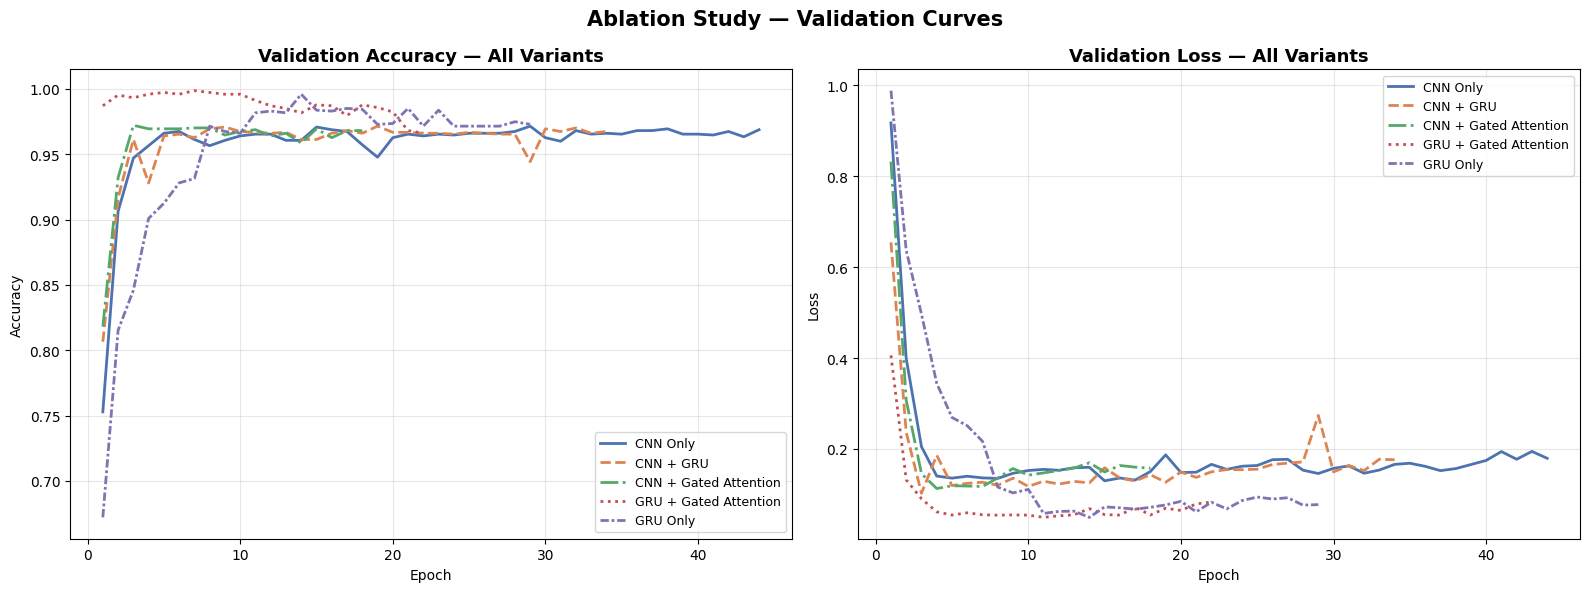

Saved: ablation_training_curves.png


In [ ]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
styles = ['-', '--', '-.', ':', (0,(3,1,1,1))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, hist) in enumerate(ALL_HISTORIES.items()):
    ep = range(1, len(hist['accuracy']) + 1)
    axes[0].plot(ep, hist['val_accuracy'], label=name,
                 color=colors[i], linestyle=styles[i], linewidth=2)
    axes[1].plot(ep, hist['val_loss'],     label=name,
                 color=colors[i], linestyle=styles[i], linewidth=2)

for ax, title, ylabel in zip(
    axes,
    ['Validation Accuracy — All Variants', 'Validation Loss — All Variants'],
    ['Accuracy', 'Loss']
):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Ablation Study — Validation Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_training_curves.png')

---
## 📊 Step 12 — Ablation Comparison Table

In [ ]:
# ── Console table ─────────────────────────────────────────────────────────────
header = f'{"Model":<30} {"Train Acc":>9} {"Val Acc":>8} {"Test Acc":>9} '\
         f'{"W-F1":>7} {"Mac-F1":>7} {"Kappa":>7} {"MCC":>7} {"AUC":>7} {"Params":>10}'
print('='*len(header))
print(header)
print('-'*len(header))

for r in ALL_RESULTS:
    print(f'{r["name"]:<30} '
          f'{r["train_acc"]:>9.4f} '
          f'{r["val_acc"]:>8.4f} '
          f'{r["test_acc"]:>9.4f} '
          f'{r["weighted_f1"]:>7.4f} '
          f'{r["macro_f1"]:>7.4f} '
          f'{r["kappa"]:>7.4f} '
          f'{r["mcc"]:>7.4f} '
          f'{r["mean_auc"]:>7.4f} '
          f'{r["n_params"]:>10,}')
print('='*len(header))

# ── Pandas display ────────────────────────────────────────────────────────────
df_results = pd.DataFrame([{
    'Model':        r['name'],
    'Train Acc':    round(r['train_acc'], 4),
    'Val Acc':      round(r['val_acc'],   4),
    'Test Acc':     round(r['test_acc'],  4),
    'W-F1':         round(r['weighted_f1'], 4),
    'Macro-F1':     round(r['macro_f1'],  4),
    'Kappa':        round(r['kappa'],     4),
    'MCC':          round(r['mcc'],       4),
    'Mean AUC':     round(r['mean_auc'],  4),
    'Params (M)':   round(r['n_params'] / 1e6, 3),
    'Stopped @Ep':  r['stopped_epoch'],
    'Time (min)':   r['train_time_min'],
} for r in ALL_RESULTS])

df_results.to_csv('ablation_results.csv', index=False)
print('\n✅ Saved ablation_results.csv')
df_results

Model                          Train Acc  Val Acc  Test Acc    W-F1  Mac-F1   Kappa     MCC     AUC     Params
--------------------------------------------------------------------------------------------------------------
CNN Only                          0.9655   0.9715    0.9325  0.9324  0.9333  0.9189  0.9190  0.9934    107,462
CNN + GRU                         0.9636   0.9715    0.9447  0.9447  0.9453  0.9336  0.9336  0.9909    429,254
CNN + Gated Attention             0.9488   0.9722    0.9182  0.9183  0.9195  0.9017  0.9022  0.9926    123,910
GRU + Gated Attention             0.9313   0.9986    0.9131  0.9132  0.9137  0.8956  0.8958  0.9912    264,646
GRU Only                          0.9313   0.9959    0.9114  0.9106  0.9112  0.8935  0.8945  0.9915    248,198

✅ Saved ablation_results.csv


,Model,Train Acc,Val Acc,Test Acc,W-F1,Macro-F1,Kappa,MCC,Mean AUC,Params (M),Stopped @Ep,Time (min)
0,CNN Only,0.9655,0.9715,0.9325,0.9324,0.9333,0.9189,0.9190,0.9934,0.107,44,1.08
1,CNN + GRU,0.9636,0.9715,0.9447,0.9447,0.9453,0.9336,0.9336,0.9909,0.429,34,1.77
2,CNN + Gated Attention,0.9488,0.9722,0.9182,0.9183,0.9195,0.9017,0.9022,0.9926,0.124,18,0.54
3,GRU + Gated Attention,0.9313,0.9986,0.9131,0.9132,0.9137,0.8956,0.8958,0.9912,0.265,22,1.40
4,GRU Only,0.9313,0.9959,0.9114,0.9106,0.9112,0.8935,0.8945,0.9915,0.248,29,1.70


---
## 📊 Step 13 — Comparison Bar Chart (Test Accuracy & F1)

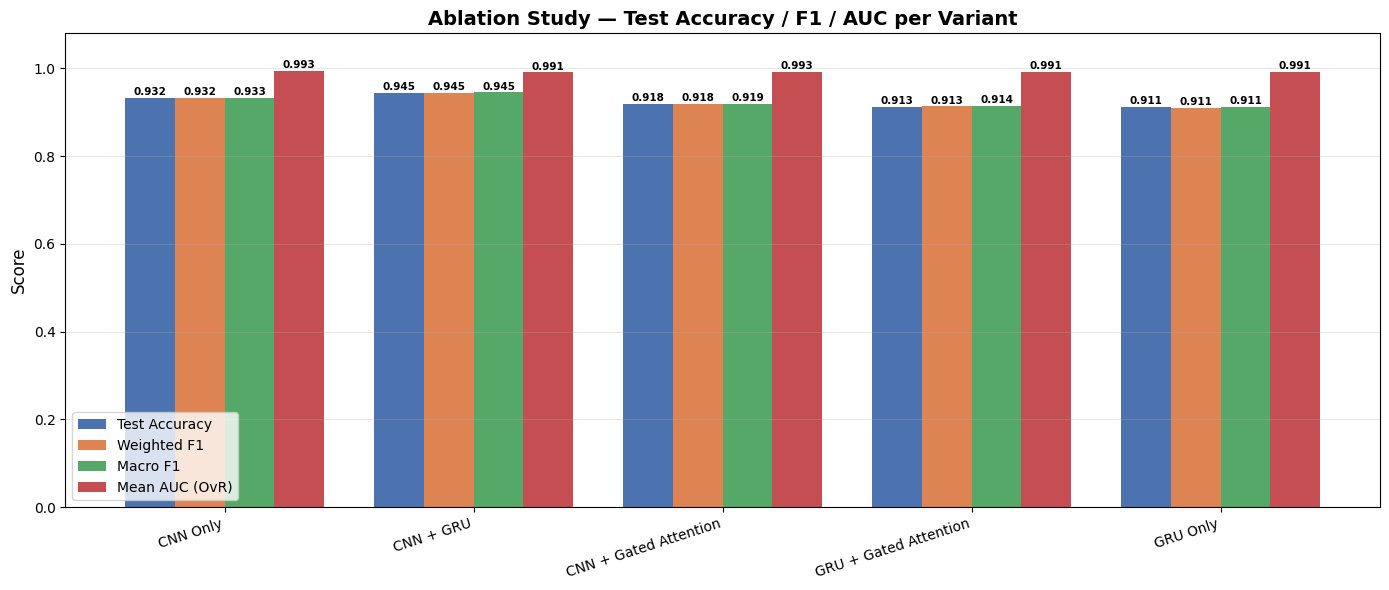

Saved: ablation_comparison_bar.png


In [ ]:
names      = [r['name'] for r in ALL_RESULTS]
test_accs  = [r['test_acc']    for r in ALL_RESULTS]
w_f1s      = [r['weighted_f1'] for r in ALL_RESULTS]
mac_f1s    = [r['macro_f1']    for r in ALL_RESULTS]
mean_aucs  = [r['mean_auc']    for r in ALL_RESULTS]

x     = np.arange(len(names))
width = 0.20

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - 1.5*width, test_accs, width, label='Test Accuracy',  color='#4C72B0')
b2 = ax.bar(x - 0.5*width, w_f1s,     width, label='Weighted F1',    color='#DD8452')
b3 = ax.bar(x + 0.5*width, mac_f1s,   width, label='Macro F1',       color='#55A868')
b4 = ax.bar(x + 1.5*width, mean_aucs, width, label='Mean AUC (OvR)', color='#C44E52')

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=18, ha='right', fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Ablation Study — Test Accuracy / F1 / AUC per Variant',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_comparison_bar.png')

---
## 🟦 Step 14 — Confusion Matrices (All 5 Variants)

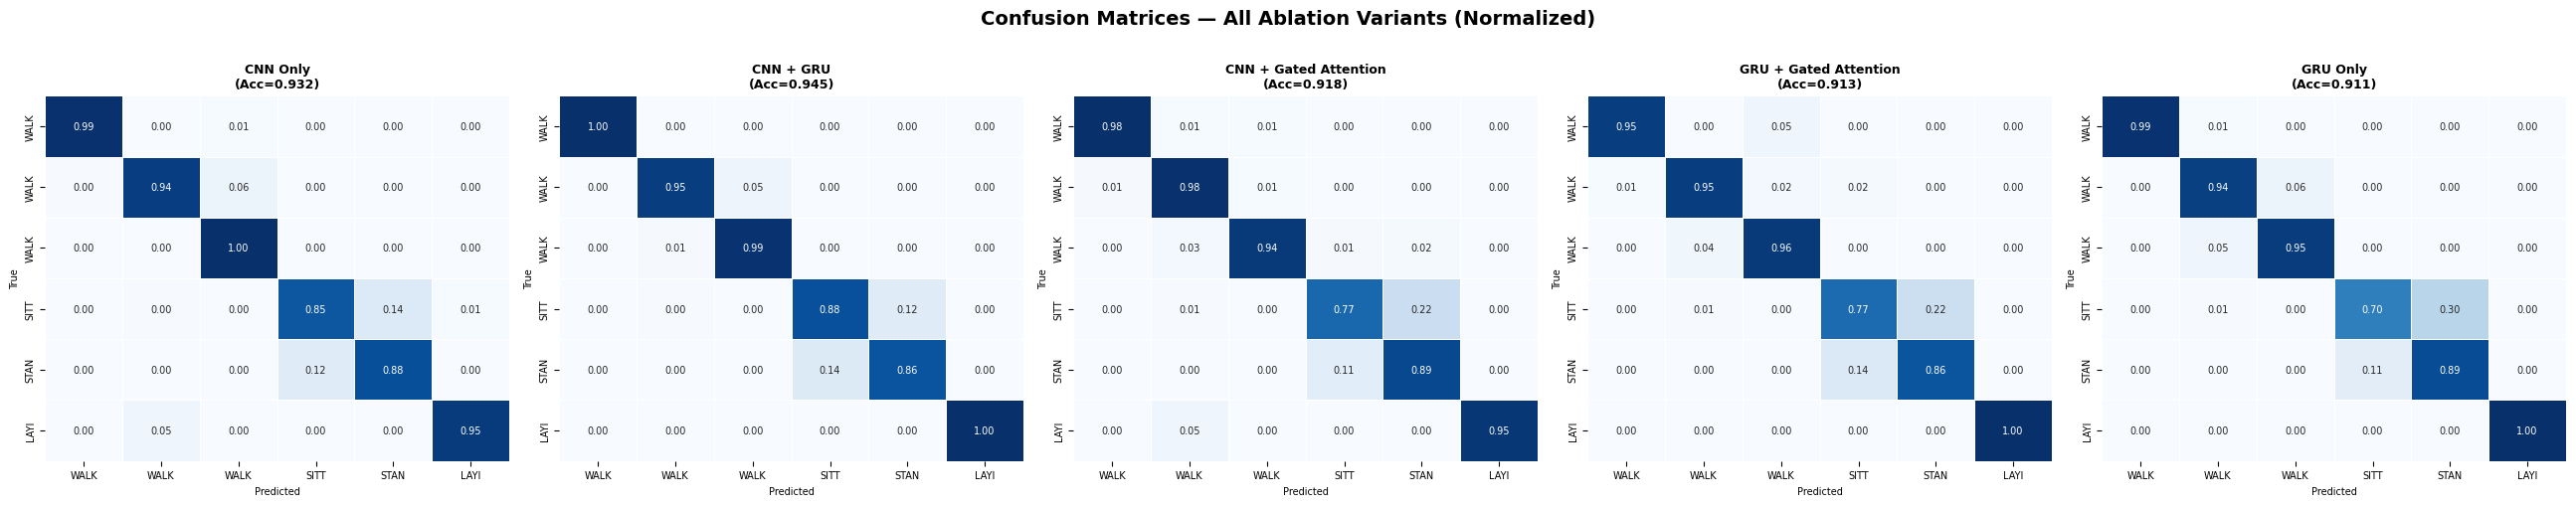

Saved: ablation_confusion_matrices.png


In [ ]:
def plot_confusion_matrix_compact(y_true, y_pred_labels, title, ax):
    cm   = confusion_matrix(y_true, y_pred_labels)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = [ACTIVITY_LABELS[i+1][:4] for i in range(N_CLASSES)]  # abbreviated
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.4, ax=ax, annot_kws={'size': 7},
                cbar=False)
    acc = accuracy_score(y_true, y_pred_labels)
    ax.set_title(f'{title}\n(Acc={acc:.3f})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=7)
    ax.set_ylabel('True', fontsize=7)
    ax.tick_params(labelsize=7)

fig, axes = plt.subplots(1, 5, figsize=(26, 5))

for ax, r in zip(axes, ALL_RESULTS):
    plot_confusion_matrix_compact(y_test, r['y_pred'], r['name'], ax)

fig.suptitle('Confusion Matrices — All Ablation Variants (Normalized)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ablation_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_confusion_matrices.png')

---
## 📉 Step 15 — ROC Curves (All Variants Overlaid, Per-Class)

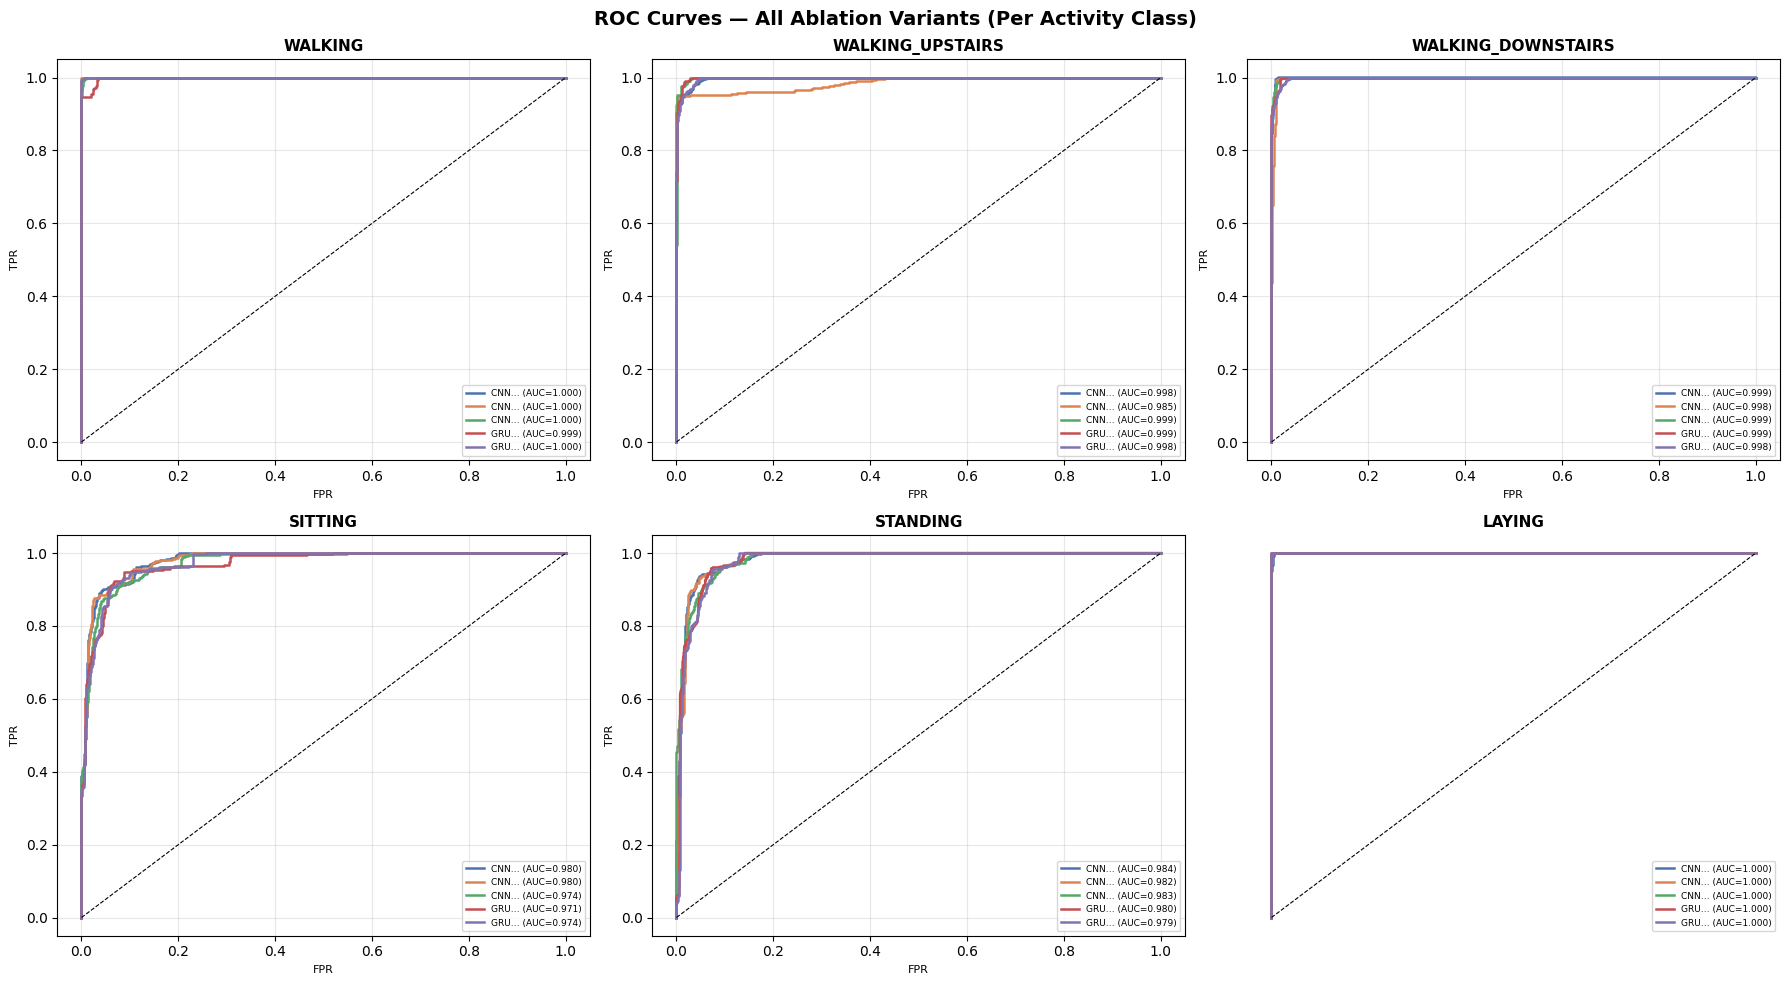

Saved: ablation_roc_curves.png


In [ ]:
y_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
variant_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for cls_idx, ax in enumerate(axes.flatten()[:N_CLASSES]):
    for r, vc in zip(ALL_RESULTS, variant_colors):
        fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], r['y_pred_proba'][:, cls_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=vc, linewidth=1.8,
                label=f"{r['name'].split(' ')[0][:7]}… (AUC={roc_auc:.3f})")

    ax.plot([0,1],[0,1],'k--', linewidth=0.8)
    ax.set_title(ACTIVITY_LABELS[cls_idx+1], fontsize=11, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=8)
    ax.set_ylabel('TPR', fontsize=8)
    ax.legend(fontsize=6.5, loc='lower right')
    ax.grid(alpha=0.3)

axes.flatten()[-1].axis('off')  # hide 6th subplot (only 6 classes, 2×3 = 6 → no spare)
fig.suptitle('ROC Curves — All Ablation Variants (Per Activity Class)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_roc_curves.png')

---
## 📊 Step 16 — Per-Class F1 Heatmap Across Variants

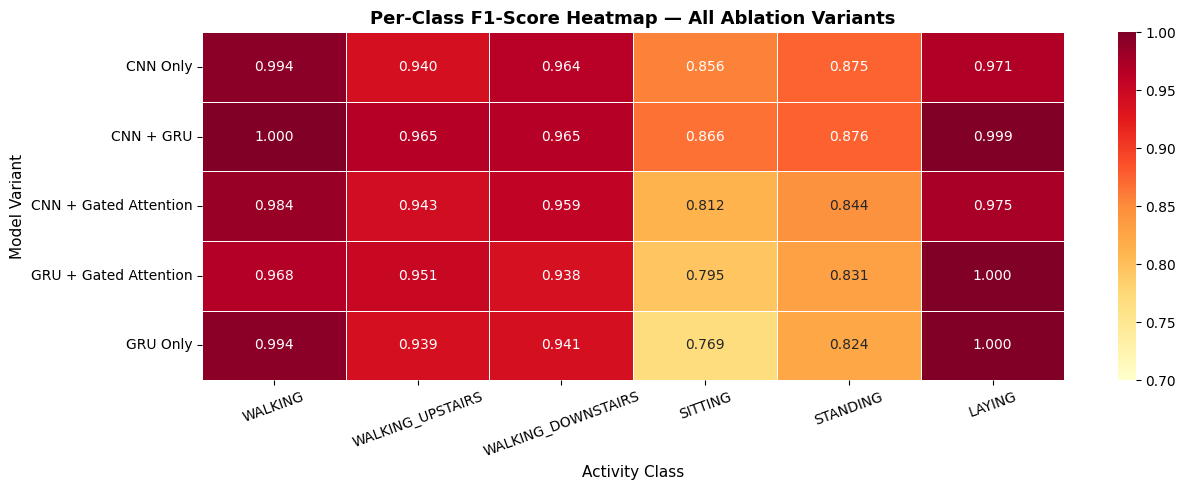

Saved: ablation_f1_heatmap.png


In [ ]:
# Build F1 matrix  [n_variants × n_classes]
f1_matrix = []
for r in ALL_RESULTS:
    _, _, f1_cls, _ = precision_recall_fscore_support(
        y_test, r['y_pred'], average=None, labels=list(range(N_CLASSES))
    )
    f1_matrix.append(f1_cls)

f1_df = pd.DataFrame(
    f1_matrix,
    index=[r['name'] for r in ALL_RESULTS],
    columns=list(ACTIVITY_LABELS.values())
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0.7, vmax=1.0,
            annot_kws={'size': 10})
ax.set_title('Per-Class F1-Score Heatmap — All Ablation Variants',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Activity Class', fontsize=11)
ax.set_ylabel('Model Variant', fontsize=11)
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('ablation_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_f1_heatmap.png')

---
## 🏅 Step 17 — Component Contribution Delta Analysis

Quantifies how much each component **adds** by looking at pairwise accuracy improvements:

| Delta | What it measures |
|---|---|
| GRU on top of CNN | `CNN+GRU` − `CNN Only` |
| Attention on top of CNN | `CNN+Attn` − `CNN Only` |
| Attention on top of GRU | `GRU+Attn` − `GRU Only` |
| CNN on top of GRU | `CNN+GRU` − `GRU Only` |
| GRU on top of CNN+Attn → Full | `Full` − `CNN+Attn` *(run your original notebook)* |

Component Contribution Δ Test Accuracy
──────────────────────────────────────────────────
  GRU added to CNN                     ++0.0122  ██
  Attention added to CNN               -0.0143  ██
  Attention added to GRU               ++0.0017  
  CNN added to GRU                     ++0.0333  ██████
  CNN+Attn vs GRU+Attn                 ++0.0051  █


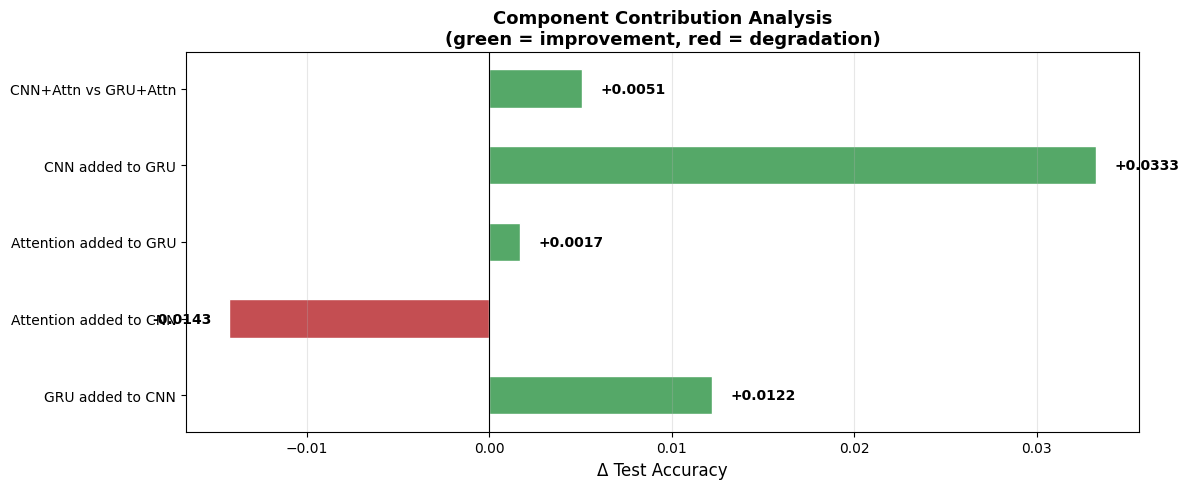

Saved: ablation_delta_analysis.png


In [ ]:
# ── Look up by name ────────────────────────────────────────────────────────────
acc = {r['name']: r['test_acc'] for r in ALL_RESULTS}

deltas = {
    'GRU added to CNN':        acc['CNN + GRU']             - acc['CNN Only'],
    'Attention added to CNN':  acc['CNN + Gated Attention'] - acc['CNN Only'],
    'Attention added to GRU':  acc['GRU + Gated Attention'] - acc['GRU Only'],
    'CNN added to GRU':        acc['CNN + GRU']             - acc['GRU Only'],
    'CNN+Attn vs GRU+Attn':    acc['CNN + Gated Attention'] - acc['GRU + Gated Attention'],
}

print('Component Contribution Δ Test Accuracy')
print('─' * 50)
for k, v in deltas.items():
    sign = '+' if v >= 0 else ''
    bar  = '█' * int(abs(v) * 200)
    print(f'  {k:<35}  {sign}{v:+.4f}  {bar}')

# Visual bar chart
fig, ax = plt.subplots(figsize=(12, 5))
bar_names = list(deltas.keys())
bar_vals  = list(deltas.values())
bar_cols  = ['#55A868' if v >= 0 else '#C44E52' for v in bar_vals]

bars = ax.barh(bar_names, bar_vals, color=bar_cols, edgecolor='white', height=0.5)
for bar, v in zip(bars, bar_vals):
    ax.text(v + (0.001 if v >= 0 else -0.001),
            bar.get_y() + bar.get_height()/2,
            f'{v:+.4f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ Test Accuracy', fontsize=12)
ax.set_title('Component Contribution Analysis\n(green = improvement, red = degradation)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_delta_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_delta_analysis.png')

---
## 🏆 Step 18 — Final Summary & Winner

In [ ]:
best_acc_r   = max(ALL_RESULTS, key=lambda r: r['test_acc'])
best_f1_r    = max(ALL_RESULTS, key=lambda r: r['weighted_f1'])
best_auc_r   = max(ALL_RESULTS, key=lambda r: r['mean_auc'])
fastest_r    = min(ALL_RESULTS, key=lambda r: r['train_time_min'])
smallest_r   = min(ALL_RESULTS, key=lambda r: r['n_params'])

print('='*65)
print('       ABLATION STUDY — FINAL SUMMARY')
print('       UCI Human Activity Recognition | 5 Variants')
print('='*65)
for r in ALL_RESULTS:
    marker = ' ⬅ BEST ACC' if r == best_acc_r else ''
    print(f"  {r['name']:<30}  "
          f"Test={r['test_acc']:.4f}  "
          f"W-F1={r['weighted_f1']:.4f}  "
          f"AUC={r['mean_auc']:.4f}"
          f"{marker}")
print('-'*65)
print(f'  🥇 Best Accuracy   : {best_acc_r["name"]}  ({best_acc_r["test_acc"]:.4f})')
print(f'  🥇 Best Weighted F1: {best_f1_r["name"]}  ({best_f1_r["weighted_f1"]:.4f})')
print(f'  🥇 Best Mean AUC   : {best_auc_r["name"]}  ({best_auc_r["mean_auc"]:.4f})')
print(f'  ⚡ Fastest Training : {fastest_r["name"]}  ({fastest_r["train_time_min"]} min)')
print(f'  🪶 Smallest Model  : {smallest_r["name"]}  ({smallest_r["n_params"]:,} params)')
print('='*65)
print()
print('🔖 Interpretation Guide:')
print('  CNN Only      → Baseline local-feature model')
print('  CNN + GRU     → Does sequential context help over CNN alone?')
print('  CNN + Attn    → Can attention replace GRU for temporal selection?')
print('  GRU + Attn    → Is CNN necessary when GRU+Attn are both present?')
print('  GRU Only      → Baseline sequential model (no spatial features)')
print()
print('  ➡️  Add the full CNN+GRU+Gated Attention result from your')
print('     original notebook to complete the ablation picture.')

       ABLATION STUDY — FINAL SUMMARY
       UCI Human Activity Recognition | 5 Variants
  CNN Only                        Test=0.9325  W-F1=0.9324  AUC=0.9934
  CNN + GRU                       Test=0.9447  W-F1=0.9447  AUC=0.9909 ⬅ BEST ACC
  CNN + Gated Attention           Test=0.9182  W-F1=0.9183  AUC=0.9926
  GRU + Gated Attention           Test=0.9131  W-F1=0.9132  AUC=0.9912
  GRU Only                        Test=0.9114  W-F1=0.9106  AUC=0.9915
-----------------------------------------------------------------
  🥇 Best Accuracy   : CNN + GRU  (0.9447)
  🥇 Best Weighted F1: CNN + GRU  (0.9447)
  🥇 Best Mean AUC   : CNN Only  (0.9934)
  ⚡ Fastest Training : CNN + Gated Attention  (0.54 min)
  🪶 Smallest Model  : CNN Only  (107,462 params)

🔖 Interpretation Guide:
  CNN Only      → Baseline local-feature model
  CNN + GRU     → Does sequential context help over CNN alone?
  CNN + Attn    → Can attention replace GRU for temporal selection?
  GRU + Attn    → Is CNN necessary when GRU+A

---
## 💾 Step 19 — Save All Results & Download

In [ ]:
# ── Save JSON results ─────────────────────────────────────────────────────────
serializable = []
for r in ALL_RESULTS:
    s = {k: v for k, v in r.items() if k not in ('y_pred', 'y_pred_proba')}
    s['train_acc']    = float(s['train_acc'])
    s['val_acc']      = float(s['val_acc'])
    s['test_acc']     = float(s['test_acc'])
    s['weighted_f1']  = float(s['weighted_f1'])
    s['macro_f1']     = float(s['macro_f1'])
    s['kappa']        = float(s['kappa'])
    s['mcc']          = float(s['mcc'])
    s['mean_auc']     = float(s['mean_auc'])
    serializable.append(s)

with open('ablation_results.json', 'w') as f:
    json.dump(serializable, f, indent=2)
print('ablation_results.json saved.')

# ── Zip everything ────────────────────────────────────────────────────────────
output_files = [
    'ablation_results.csv',
    'ablation_results.json',
    'ablation_training_curves.png',
    'ablation_comparison_bar.png',
    'ablation_confusion_matrices.png',
    'ablation_roc_curves.png',
    'ablation_f1_heatmap.png',
    'ablation_delta_analysis.png',
    'class_distribution.png',
]

with zipfile.ZipFile('HAR_Ablation_Results.zip', 'w') as zf:
    for fname in output_files:
        if os.path.exists(fname):
            zf.write(fname)
            print(f'  + {fname}')
        else:
            print(f'  ⚠️  missing: {fname}')

print('\nAll outputs bundled → HAR_Ablation_Results.zip')
files.download('HAR_Ablation_Results.zip')

ablation_results.json saved.
  + ablation_results.csv
  + ablation_results.json
  + ablation_training_curves.png
  + ablation_comparison_bar.png
  + ablation_confusion_matrices.png
  + ablation_roc_curves.png
  + ablation_f1_heatmap.png
  + ablation_delta_analysis.png
  + class_distribution.png

All outputs bundled → HAR_Ablation_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📌 Architecture Reference

| Variant | Input Path | Temporal Modeling | Context Selection | Head |
|---------|-----------|-------------------|-------------------|------|
| **CNN Only** | Raw → CNN | ❌ | GlobalAvgPool | Dense-128 → 6 |
| **CNN + GRU** | Raw → CNN → GRU | BiGRU (final state) | ❌ | Dense-128 → 6 |
| **CNN + Gated Attn** | Raw → CNN | ❌ | GatedAttention | Dense-128 → 6 |
| **GRU + Gated Attn** | Raw → GRU | BiGRU (all states) | GatedAttention | Dense-128 → 6 |
| **GRU Only** | Raw → GRU | BiGRU (final state) | ❌ | Dense-128 → 6 |
| **Full (original)** | Raw → CNN → GRU | BiGRU (all states) | GatedAttention | Dense-128 → 6 |

### CNN blocks (shared across variants that use CNN)
```
Conv1D(64,k=3) → BN → ReLU → Conv1D(64,k=3) → BN → ReLU → MaxPool(2) → Drop(0.2)
Conv1D(128,k=3) → BN → ReLU → Conv1D(128,k=3) → BN → ReLU → MaxPool(2) → Drop(0.2)
```

### GRU blocks (shared across variants that use GRU)
```
BiGRU(128, return_seq=True, dropout=0.2)
BiGRU(64,  return_seq=True|False, dropout=0.2)   ← True when feeding Attention
```

### Gated Attention (shared)
```
score = tanh(H @ W_h)        — content relevance
gate  = sigmoid(H @ W_g)     — information gate
α     = softmax(score * gate) — gated weights
ctx   = Σ α_t · H_t           — context vector
```

### Training config (same for all)
- Optimizer: Adam + CosineDecayRestarts (initial LR=1e-3)
- EarlyStopping: patience=15, monitor=val_accuracy
- Batch size: 64 | Max epochs: 80
- Subject-level splits (no data leakage)